In [1]:
import pandas, numpy

In [2]:
import sklearn, sklearn.preprocessing, sklearn.decomposition

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

# 0. user-defined variables

In [4]:
input_file = '/Users/adrian/research/016.saudarkrokur/results/deseq2/DESeq2_TPM_values.tsv'

# 1. read expression

In [5]:
expression = pandas.read_csv(input_file, sep='\t', index_col=0)
print(expression.shape)
expression

(20196, 15)


,h1M8_1,h1M8_2,h1M8_3,h2F14_1,h2F14_2,h2F14_3,h2M8_1,h2M8_2,h2M8_3,KO_1,KO_2,KO_3,WT_1,WT_2,WT_3
FBgn0000008,7.888992,2.404364,7.641325,4.496739,4.474108,3.101558,4.169942,1.109283,2.990706,1.868627,6.349273,2.046127,3.973536,4.069418,13.169861
FBgn0000014,20.584356,9.116074,16.522137,15.028010,21.370556,14.917465,8.706565,3.393639,9.797755,9.116257,13.886094,7.729379,17.593189,17.433641,26.561830
FBgn0000015,4.750318,2.421290,4.041314,3.888815,5.497831,3.691880,3.295904,1.335717,2.375402,2.341026,4.271938,2.319874,5.166222,4.948848,5.854713
FBgn0000017,18.593702,10.642545,16.094865,12.066664,15.937162,4.499557,9.407700,3.693964,8.149117,6.646698,9.728445,5.603754,13.220405,15.056392,19.031383
FBgn0000018,7.344876,5.077850,5.495519,6.130012,5.916365,5.738847,6.771208,4.022657,6.456481,4.897385,5.102448,3.645305,8.031238,8.084451,6.875136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
RR51048_transposable_element,0.000000,0.000000,0.000000,0.000000,0.010833,0.000000,0.000000,0.013156,0.000000,0.017752,0.017819,0.000000,0.109559,0.000000,0.098044
RR51093_transposable_element,0.000000,0.000000,0.378845,0.000000,0.391035,1.290643,0.098497,1.382451,0.222965,0.232897,0.465807,0.000000,0.398241,0.560288,0.201621
RR51475_transposable_element,0.731425,1.404666,2.041584,0.587566,1.355312,17.322956,10.440089,45.617028,5.626746,4.394941,2.425542,2.004484,13.506209,17.595002,7.525028
RR51477_transposable_element,0.009972,0.017888,0.021606,0.021574,0.005813,0.014672,0.098988,0.085491,0.032967,0.009189,0.033684,0.016833,0.042574,0.000000,0.106921


In [6]:
samples_to_exclude = ['h2M8_2', 'h2F14_3']
expression.drop(samples_to_exclude, axis=1, inplace=True)

# 3. filter and transform

In [7]:
substantial_expression = expression[expression.max(axis=1) >= 2]
high_expression = expression[expression.max(axis=1) >= 100]

print(substantial_expression.shape)
print(high_expression.shape)

(11161, 13)
(1359, 13)


In [8]:
transpose = substantial_expression.transpose()
pca_substantial_expression = numpy.log2(transpose + 1)

transpose = high_expression.transpose()
pca_high_expression = numpy.log2(transpose + 1)

# 4. visualize substantial expression

In [9]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_substantial_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.41751059 0.17434899]


In [10]:
my_colors = ['gold']*3 + ['skyblue']*2 + ['tab:red']*2 + ['black']*3 + ['tab:green']*3
my_markers = ['o']*7 + ['s']*6

legend_elements = [
    
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='gold', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='skyblue', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:red', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='s', markerfacecolor='black', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='s', markerfacecolor='tab:green', markeredgecolor='white', markersize=20, alpha=2/3)
    
]

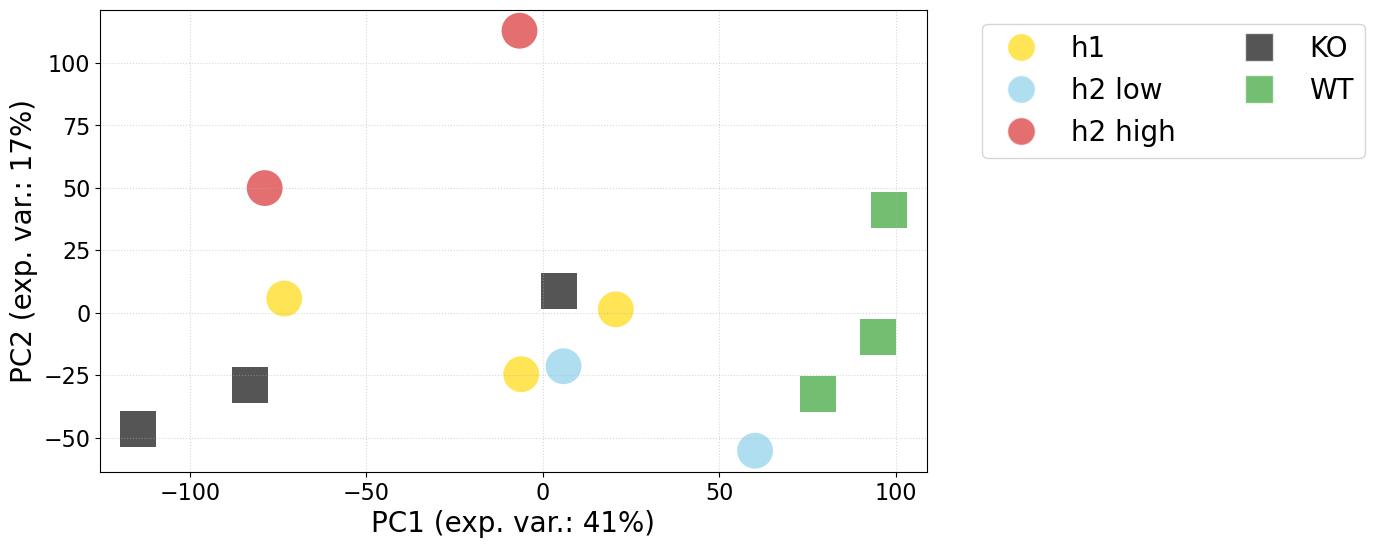

In [11]:
for i in range(len(new)):
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=666, c=my_colors[i], marker=my_markers[i], alpha=2/3, edgecolors='none')

matplotlib.pyplot.legend(legend_elements, ['h1', 'h2 low', 'h2 high', 'KO', 'WT'], ncol=2, loc='upper left', bbox_to_anchor=(1.05, 1))
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(alpha=0.5, ls=':')

matplotlib.pyplot.show()
#matplotlib.pyplot.savefig('pca.svg')

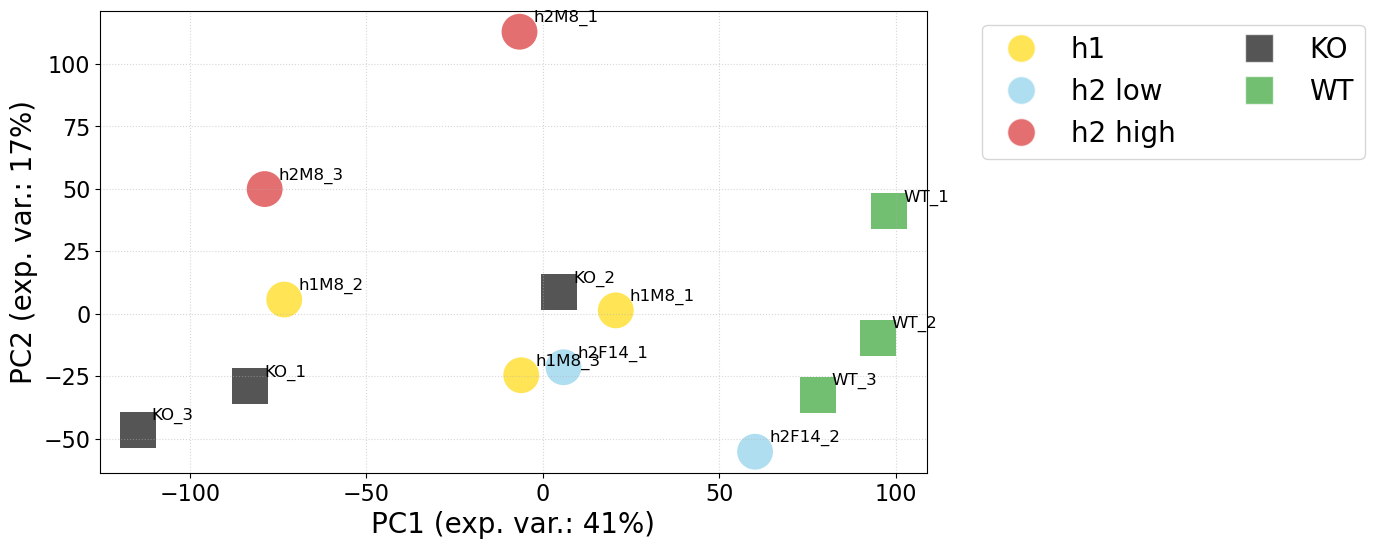

In [12]:
for i in range(len(new)):
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=666, c=my_colors[i], marker=my_markers[i], alpha=2/3, edgecolors='none')

    epsilon = 4
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, expression.columns[i], size=12)

matplotlib.pyplot.legend(legend_elements, ['h1', 'h2 low', 'h2 high', 'KO', 'WT'], ncol=2, loc='upper left', bbox_to_anchor=(1.05, 1))
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(alpha=0.5, ls=':')

# 4. visualize high expression

In [13]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_high_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.40788184 0.14774522]


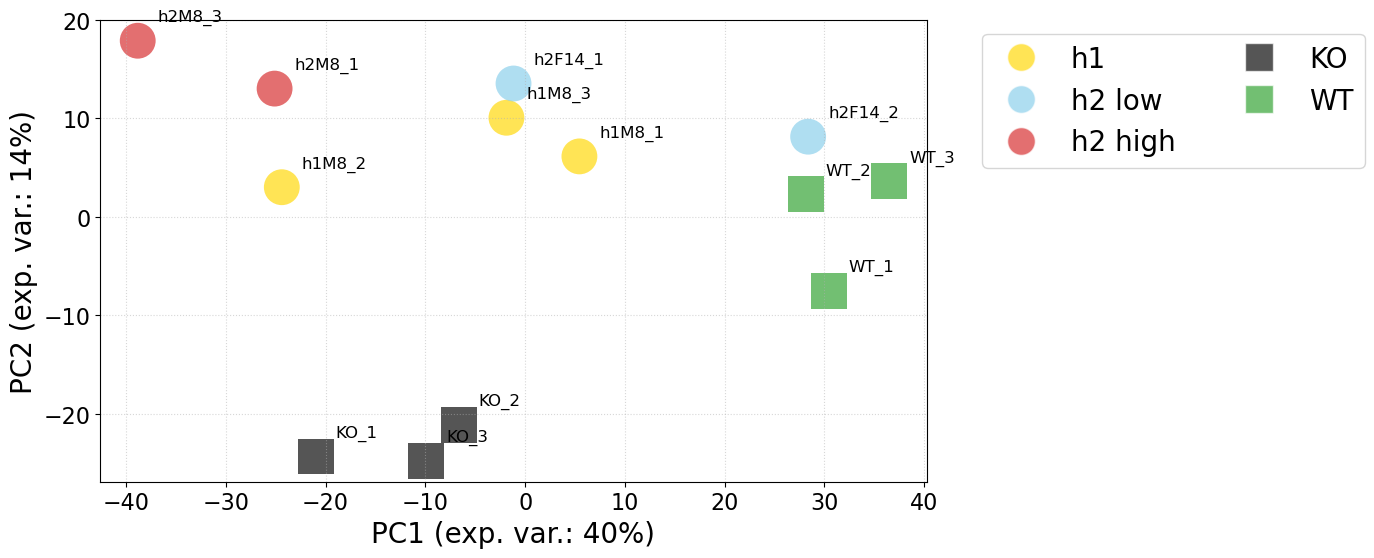

In [15]:
for i in range(len(new)):
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=666, c=my_colors[i], marker=my_markers[i], alpha=2/3, edgecolors='none')
    epsilon = 2
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, expression.columns[i], size=12)
matplotlib.pyplot.legend(legend_elements, ['h1', 'h2 low', 'h2 high', 'KO', 'WT'], ncol=2, loc='upper left', bbox_to_anchor=(1.05, 1))
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(alpha=0.5, ls=':')
matplotlib.pyplot.show()